### Imports


In [98]:
import numpy as np
import re
import tensorflow as tf

from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

### Data

In [99]:
texts = [
    # Positive
    "I love this product.",
    "This movie is amazing.",
    "The food was delicious.",
    "I am very happy today.",
    "The service was excellent.",
    "The noodles were tasty.",
    "The food was good.",
    "The staff was friendly.",
    "The experience was great.",
    "The product worked well.",

    # Negative
    "I hate this product.",
    "This movie is boring.",
    "The food was terrible.",
    "I am very sad today.",
    "The service was bad.",
    "The noodles were not tasty.",
    "The food was not good.",
    "The movie was not amazing.",
    "The service was not excellent.",
    "I am not happy today.",

    # Neutral
    "This product is okay.",
    "The movie was average.",
    "The food was normal.",
    "I feel fine today.",
    "The service was acceptable.",
    "The noodles were okay.",
    "The experience was neither good nor bad.",
    "The product was average.",
    "The staff was available.",
    "The food was decent."
]

# 0 = Negative, 1 = Positive, 2 = Neutral
labels = np.array([
    # Positive
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

    # Negative
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

    # Neutral
    2, 2, 2, 2, 2, 2, 2, 2, 2, 2
])

### Preprocessing

In [100]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text


def clean_and_tokenize(text):
    text = clean_text(text)
    words = text.split()
    return words

### Word2Vec Model


In [101]:
tokens = []

for text in texts:
    words = clean_and_tokenize(text)
    tokens.append(words)

print(tokens)

[['i', 'love', 'this', 'product'], ['this', 'movie', 'is', 'amazing'], ['the', 'food', 'was', 'delicious'], ['i', 'am', 'very', 'happy', 'today'], ['the', 'service', 'was', 'excellent'], ['the', 'noodles', 'were', 'tasty'], ['the', 'food', 'was', 'good'], ['the', 'staff', 'was', 'friendly'], ['the', 'experience', 'was', 'great'], ['the', 'product', 'worked', 'well'], ['i', 'hate', 'this', 'product'], ['this', 'movie', 'is', 'boring'], ['the', 'food', 'was', 'terrible'], ['i', 'am', 'very', 'sad', 'today'], ['the', 'service', 'was', 'bad'], ['the', 'noodles', 'were', 'not', 'tasty'], ['the', 'food', 'was', 'not', 'good'], ['the', 'movie', 'was', 'not', 'amazing'], ['the', 'service', 'was', 'not', 'excellent'], ['i', 'am', 'not', 'happy', 'today'], ['this', 'product', 'is', 'okay'], ['the', 'movie', 'was', 'average'], ['the', 'food', 'was', 'normal'], ['i', 'feel', 'fine', 'today'], ['the', 'service', 'was', 'acceptable'], ['the', 'noodles', 'were', 'okay'], ['the', 'experience', 'was', 

In [102]:
word_model = Word2Vec(
    sentences=tokens,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=1
)

In [103]:
def get_sentence_vectors(tokens, word_model):
    sentence_vectors = []

    for sentence in tokens:
        word_vectors = []

        for word in sentence:
            if word in word_model.wv:
                word_vectors.append(word_model.wv[word])

        if len(word_vectors) > 0:
            sentence_vector = np.mean(word_vectors, axis=0)
        else:
            sentence_vector = np.zeros(word_model.vector_size)

        sentence_vectors.append(sentence_vector)

    return np.array(sentence_vectors)


X_word = get_sentence_vectors(tokens, word_model)

print("X_word shape:", X_word.shape)
print("labels shape:", labels.shape)

X_word shape: (30, 50)
labels shape: (30,)


In [104]:
model2 = Sequential([
    Input(shape=(X_word.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model2.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,211 (8.64 KB)

 Trainable params: 2,211 (8.64 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
history_word2vec = model2.fit(
    X_word,
    labels,
    epochs=100,
    verbose=1
)

word_loss, word_accuracy = model2.evaluate(X_word, labels)

print("Word2Vec Model Accuracy:", word_accuracy)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step - accuracy: 0.3667 - loss: 1.0994
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 1.0974
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3667 - loss: 1.0966
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5667 - loss: 1.0957
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6333 - loss: 1.0946
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6667 - loss: 1.0933
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5667 - loss: 1.0919
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5667 - loss: 1.0903
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6000 - loss: 1.0884
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6333 - loss: 1.0863
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6667 - loss: 1.0839
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6333 - l

### TF-IDF Model

In [106]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

X_tf = vectorizer.fit_transform(texts).toarray()

print("X_tf shape:", X_tf.shape)
print("labels shape:", labels.shape)

X_tf shape: (30, 100)
labels shape: (30,)


In [107]:
model_tf = Sequential([
    Input(shape=(X_tf.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model_tf.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_tf.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,811 (14.89 KB)

 Trainable params: 3,811 (14.89 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
history_tfidf = model_tf.fit(
    X_tf,
    labels,
    epochs=30,
    verbose=1
)

tf_loss, tf_accuracy = model_tf.evaluate(X_tf, labels)

print("TF-IDF Model Accuracy:", tf_accuracy)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step - accuracy: 0.3333 - loss: 1.1027
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5333 - loss: 1.0563
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7000 - loss: 1.0159
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8667 - loss: 0.9760
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9000 - loss: 0.9356
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9000 - loss: 0.8920
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9000 - loss: 0.8455
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9000 - loss: 0.7966
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9000 - loss: 0.7450
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9000 - loss: 0.6933
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9333 - loss: 0.6383
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9333 - loss: 0.5817


### Model Comparision

In [109]:
class_names = {
    0: "Negative",
    1: "Positive",
    2: "Neutral"
}

def compare_models(new_texts):
    if isinstance(new_texts, str):
        new_texts = [new_texts]


    new_tokens = []

    for text in new_texts:
        words = clean_and_tokenize(text)
        new_tokens.append(words)

    new_word_vectors = get_sentence_vectors(new_tokens, word_model)

    word2vec_predictions = model2.predict(new_word_vectors)
    word2vec_classes = np.argmax(word2vec_predictions, axis=1)


    new_tfidf_vectors = vectorizer.transform(new_texts).toarray()

    tfidf_predictions = model_tf.predict(new_tfidf_vectors)
    tfidf_classes = np.argmax(tfidf_predictions, axis=1)


    for i, text in enumerate(new_texts):
        print("=" * 80)
        print("Text:", text)
        print()

        print("Word2Vec")
        print("Predicted class:", class_names[word2vec_classes[i]])
        print("Probabilities:")
        print("Negative:", word2vec_predictions[i][0])
        print("Positive:", word2vec_predictions[i][1])
        print("Neutral :", word2vec_predictions[i][2])
        print()

        print("TF-IDF")
        print("Predicted class:", class_names[tfidf_classes[i]])
        print("Probabilities:")
        print("Negative:", tfidf_predictions[i][0])
        print("Positive:", tfidf_predictions[i][1])
        print("Neutral :", tfidf_predictions[i][2])
        print()

In [110]:
compare_models([
    "The noodles were not tasty",
    "The noodles were tasty",
    "The movie was okay",
    "The service was terrible",
    "The food was not good",
    "The staff was friendly",
    "The experience was neither good nor bad"
])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Text: The noodles were not tasty

Word2Vec
Predicted class: Negative
Probabilities:
Negative: 0.9688723
Positive: 0.017920624
Neutral : 0.013207062

TF-IDF
Predicted class: Negative
Probabilities:
Negative: 0.98819226
Positive: 0.0117995385
Neutral : 8.255469e-06

Text: The noodles were tasty

Word2Vec
Predicted class: Positive
Probabilities:
Negative: 0.0011617058
Positive: 0.85034704
Neutral : 0.14849123

TF-IDF
Predicted class: Positive
Probabilities:
Negative: 0.013381534
Positive: 0.98247427
Neutral : 0.0041442225

Text: The movie was okay

Word2Vec
Predicted class: Neutral
Probabilities:
Negative: 0.001028565
Positive: 0.05739457
Neutral : 0.94157684

TF-IDF
Predicted class: Neutral
Probabilities:
Negative: 0.0023394777
Positive: 0.0015663625
Neutral : 0.99609417

Text: The service was terrible

Word2Vec
Predicted class: Negative
Probabilities:
Negative: 0.9939135
Positive: 0.0010462261
Neutral : 0.005040

In [111]:
print("Final Model Comparison")
print("----------------------")
print("Word2Vec:", word_accuracy)
print("TF-IDF:", tf_accuracy)

Final Model Comparison
----------------------
Word2Vec: 0.9666666388511658
TF-IDF: 1.0


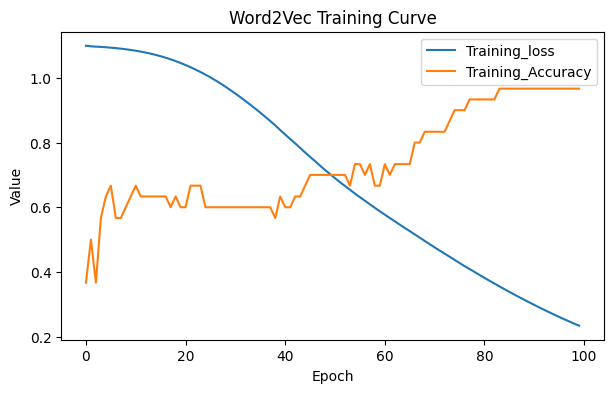

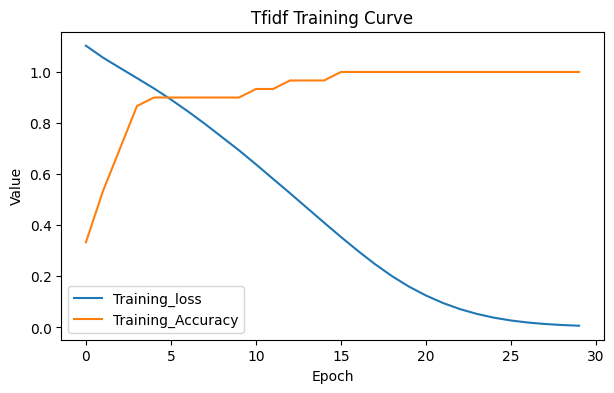

In [112]:
import matplotlib.pyplot as plt
plt.figure(figsize = (7,4))
plt.plot(history_word2vec.history['loss'], label='Training_loss')
plt.plot(history_word2vec.history['accuracy'], label='Training_Accuracy')
plt.title("Word2Vec Training Curve")
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()

import matplotlib.pyplot as plt
plt.figure(figsize = (7,4))
plt.plot(history_tfidf.history['loss'], label='Training_loss')
plt.plot(history_tfidf.history['accuracy'], label='Training_Accuracy')
plt.title("Tfidf Training Curve")
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()